<a href="https://colab.research.google.com/github/Kshitiz83/Covid-19-Impact-Data-Analysis-Analyzed-the-impact-of-Covid-19/blob/main/Covid_19_Impact_Data_Analysis_Analyzed_the_impact_of_Covid_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports necessary libraries (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`) and then loads the `owid-covid-data.csv` file into a pandas DataFrame named `df`. Finally, it displays the first 3 rows of the DataFrame to provide a quick overview of the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/owid-covid-data.csv')
df.head(3)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


This cell uses the `.dtypes` attribute to display the data type of each column in the DataFrame `df`. This helps in understanding the current data types and identifying if any conversions are needed.

In [ ]:
df.dtypes


,0
iso_code,object
continent,object
location,object
date,object
total_cases,float64
...,...
population,float64
excess_mortality_cumulative_absolute,float64
excess_mortality_cumulative,float64
excess_mortality,float64


This cell calculates the index of the 'new_deaths_smoothed' column and then filters the DataFrame `df` to keep all columns from the beginning up to and including 'new_deaths_smoothed'. This effectively truncates the DataFrame to a specific set of columns.

In [ ]:
death_column_index = df.columns.get_loc('new_deaths_smoothed')
df = df.iloc[:, :death_column_index + 1]


This cell first prints the column names of the modified `df` DataFrame. Then, it uses `display(df.head())` to show the first few rows of the DataFrame, confirming the column reduction.

In [ ]:
print(df.columns)
display(df.head())

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed'],
      dtype='object')


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN


This cell extracts 'year', 'month', and 'day' from the 'date' column, converts them to integer types, and creates new columns in the DataFrame. It then drops the original 'date' column and displays the first 3 rows of the updated DataFrame.

In [ ]:
df['year']=df['date'].str.split('-',expand=True)[0].astype(int)
df['month']=df['date'].str.split('-',expand=True)[1].astype(int)
df['day']=df['date'].str.split('-',expand=True)[2].astype(int)
df.drop(columns=['date'],inplace=True)
display(df.head(3))


,iso_code,continent,location,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,year,month,day
0,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,2020,1,3
1,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,2020,1,4
2,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,2020,1,5


This cell calculates and displays the count of missing (null) values for each column in the DataFrame `df` using `df.isnull().sum()`. This helps identify columns with missing data that need to be handled.

In [ ]:
df.isnull().sum()

,0
iso_code,0
continent,14352
location,0
total_cases,35741
new_cases,8448
new_cases_smoothed,9712
total_deaths,56298
new_deaths,8373
new_deaths_smoothed,9603
year,0


This cell handles missing values in the DataFrame. It fills numerical columns ('total_cases', 'new_cases', etc.) with `0` and converts them to `int64` type. It also fills missing values in the 'continent' column with 'Unknown'. Finally, it displays the updated count of null values to confirm that missing values have been addressed.

In [ ]:


numerical_cols_to_fill=['total_cases','new_cases','new_cases_smoothed','total_deaths','new_deaths','new_deaths_smoothed']
for col in numerical_cols_to_fill:
  df[col]=df[col].fillna(0)
  df[col]=df[col].astype('int64')

df['continent']=df['continent'].fillna('Unknown')
df.isnull().sum()


,0
iso_code,0
continent,0
location,0
total_cases,0
new_cases,0
new_cases_smoothed,0
total_deaths,0
new_deaths,0
new_deaths_smoothed,0
year,0


This cell aggregates 'new_deaths_smoothed' by 'year' and 'month', creating a 'year_month' column. It then visualizes the total deaths smoothed month by month using a bar plot. The x-axis labels are rotated for better readability.

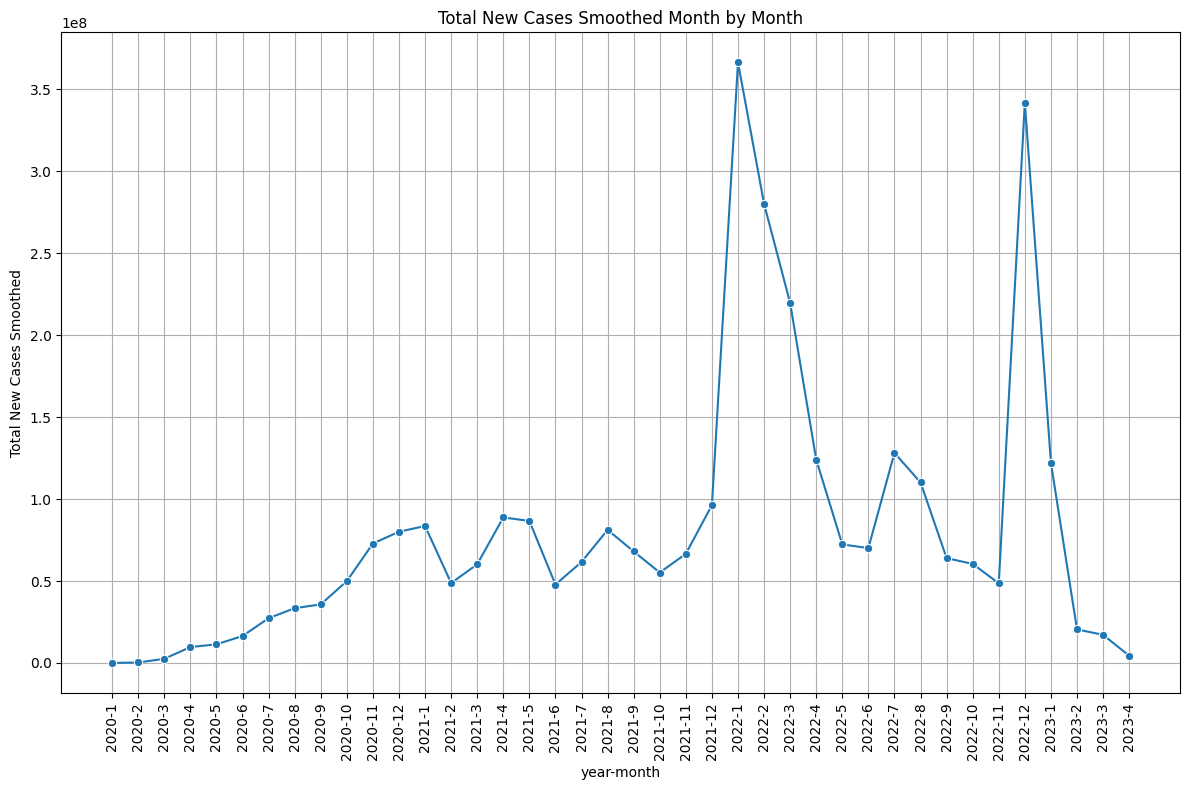

In [ ]:


cases_month_by_month=df.groupby(['year','month'])['new_cases_smoothed'].sum().reset_index()
cases_month_by_month['year_month']=cases_month_by_month['year'].astype(str) + '-'+ cases_month_by_month['month'].astype(str)

plt.figure(figsize=(12,8))
sns.lineplot(x='year_month',y='new_cases_smoothed',data=cases_month_by_month,marker='o')
plt.title('Total New Cases Smoothed Month by Month')
plt.xlabel('year-month')
plt.ylabel('Total New Cases Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell calculates the total 'new_cases_smoothed' grouped by 'year' and 'month'. It then creates a 'year_month' column for plotting. Finally, it generates and displays a line plot showing the trend of total new cases smoothed month by month.

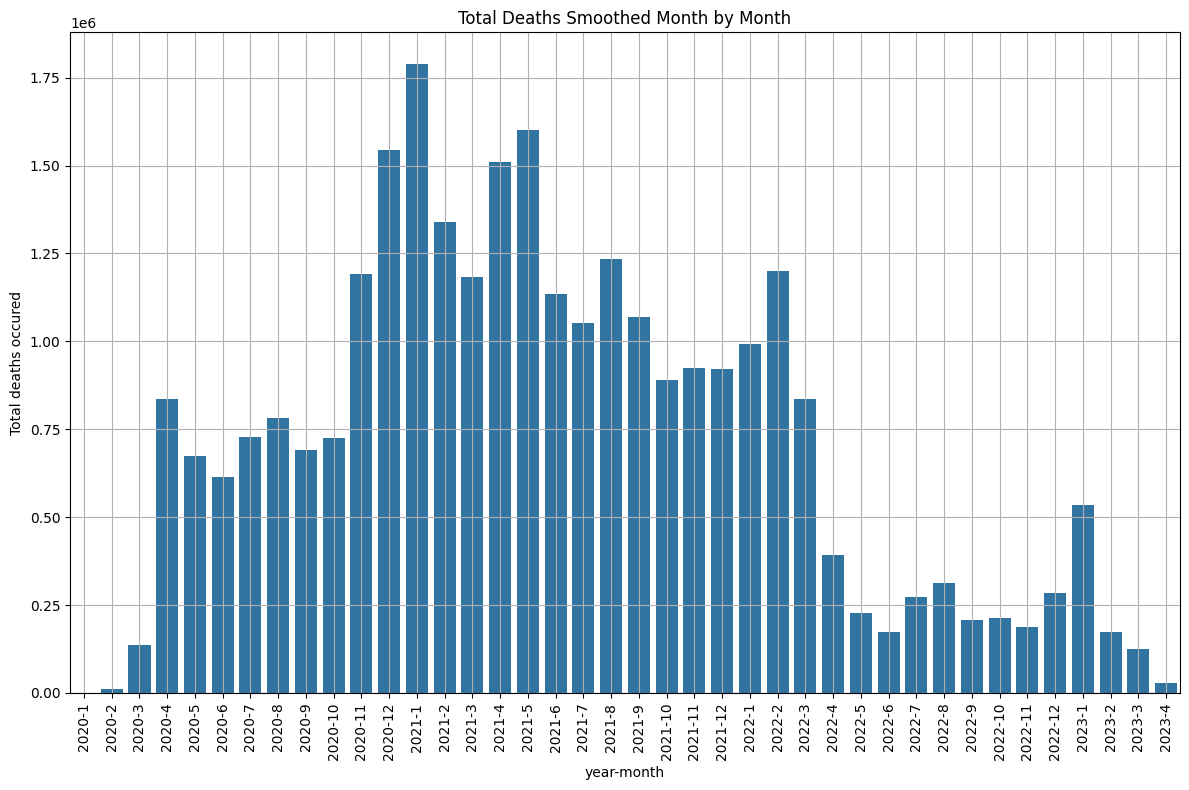

In [ ]:
deaths_month_by_month=df.groupby(['year','month'])['new_deaths_smoothed'].sum().reset_index()
deaths_month_by_month['year_month']=deaths_month_by_month['year'].astype(str)+'-'+deaths_month_by_month['month'].astype(str)

plt.figure(figsize=(12,8))
sns.barplot(x='year_month',y='new_deaths_smoothed',data=deaths_month_by_month)
plt.title('Total Deaths Smoothed Month by Month')
plt.xlabel('year-month')
plt.ylabel('Total deaths occured')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()















This cell filters the DataFrame for 'India', aggregates 'new_deaths_smoothed' by 'year' and 'month', and creates a 'year-month' column. It then plots a line chart showing the smoothed death trend for India over time.

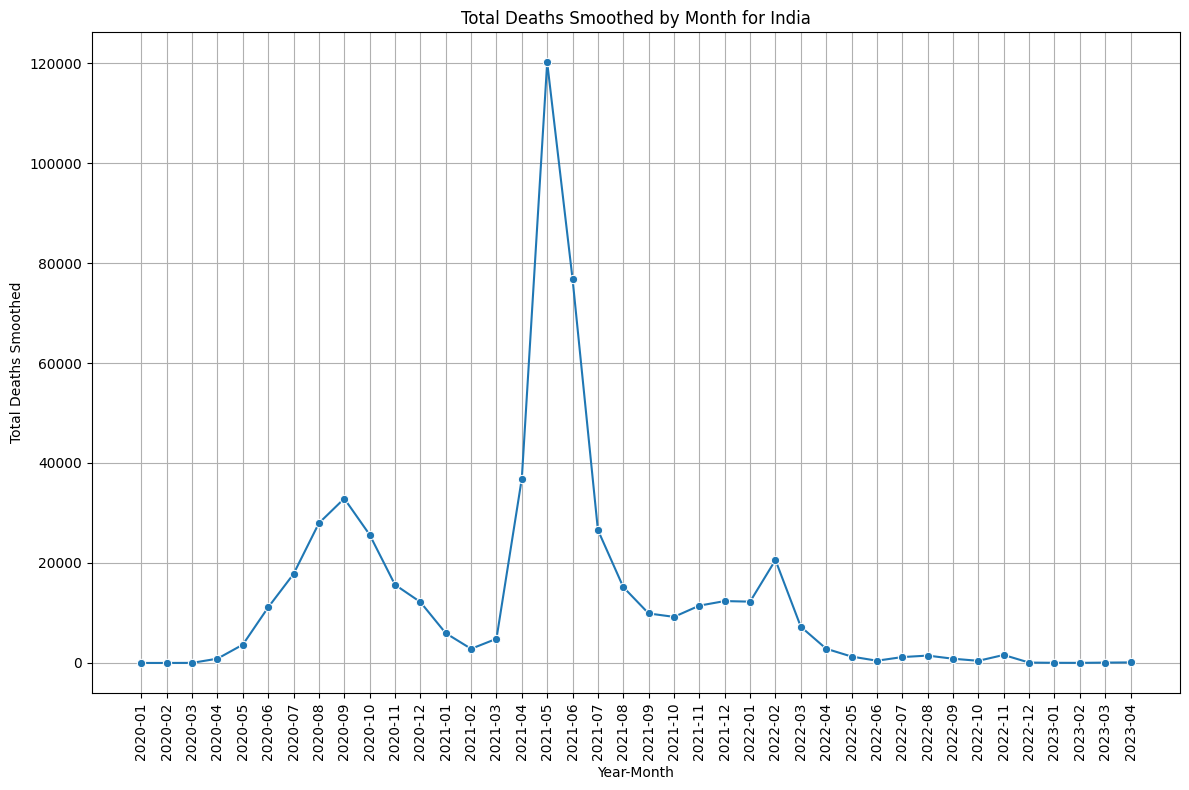

In [ ]:
india_death_month_by_month=df[df['location']=='India'].groupby(['year','month'])['new_deaths_smoothed'].sum().reset_index()
india_death_month_by_month['year-month']=india_death_month_by_month['year'].astype(str)+'-'+india_death_month_by_month['month'].astype(str).str.zfill(2)

plt.figure(figsize=(12,8))
sns.lineplot(x='year-month',y='new_deaths_smoothed',data=india_death_month_by_month,marker='o')
plt.title('Total Deaths Smoothed by Month for India')
plt.xlabel('Year-Month')
plt.ylabel('Total Deaths Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell filters the DataFrame for 'United States', aggregates 'new_deaths_smoothed' by 'year' and 'month', and creates a 'year-month' column. It then plots a line chart showing the smoothed death trend for the United States over time.

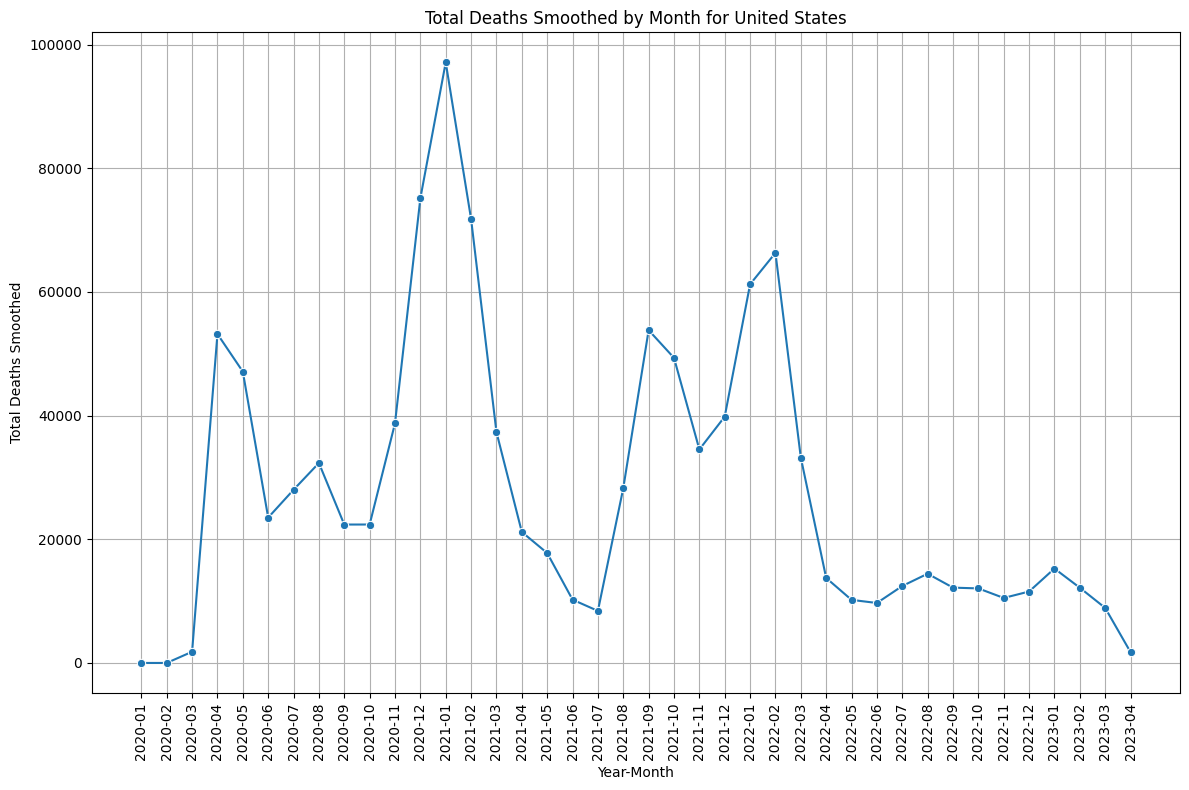

In [ ]:
us_death_month_by_month=df[df['location']=='United States'].groupby(['year','month'])['new_deaths_smoothed'].sum().reset_index()
us_death_month_by_month['year-month']=us_death_month_by_month['year'].astype(str)+'-'+us_death_month_by_month['month'].astype(str).str.zfill(2)

plt.figure(figsize=(12,8))
sns.lineplot(x='year-month',y='new_deaths_smoothed',data=us_death_month_by_month,marker='o')
plt.title('Total Deaths Smoothed by Month for United States')
plt.xlabel('Year-Month')
plt.ylabel('Total Deaths Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell filters the DataFrame for 'China', aggregates 'new_deaths_smoothed' by 'year' and 'month', and creates a 'year-month' column. It then plots a line chart showing the smoothed death trend for China over time.

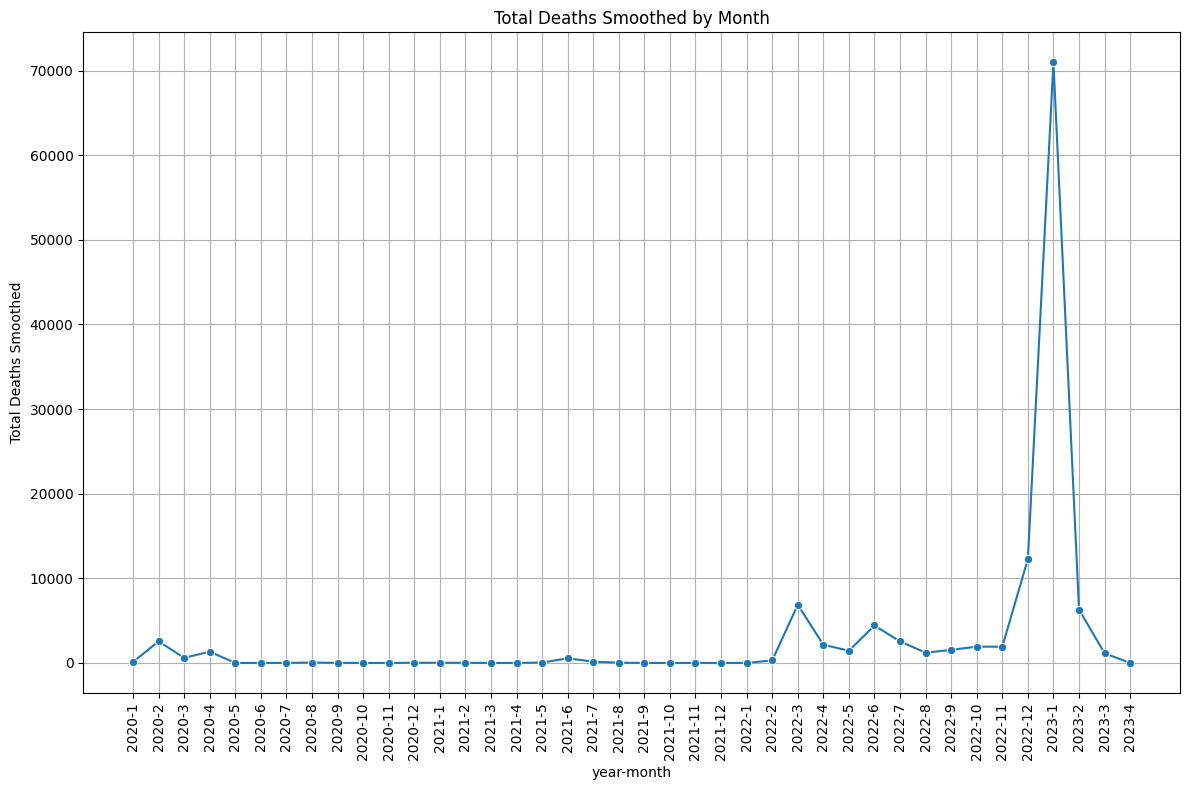

In [ ]:
china_death_month_by_month=df[df['location']=='China'].groupby(['year','month'])['new_deaths_smoothed'].sum().reset_index()
china_death_month_by_month['year-month']=china_death_month_by_month['year'].astype(str)+'-'+china_death_month_by_month['month'].astype(str)

plt.figure(figsize=(12,8))
sns.lineplot(x='year-month',y='new_deaths_smoothed',data=china_death_month_by_month,marker='o')
plt.title('Total Deaths Smoothed by Month')
plt.xlabel('year-month')
plt.ylabel('Total Deaths Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell filters the DataFrame for 'Russia', aggregates 'new_deaths_smoothed' by 'year' and 'month', and creates a 'year-month' column. It then plots a line chart showing the smoothed death trend for Russia over time.

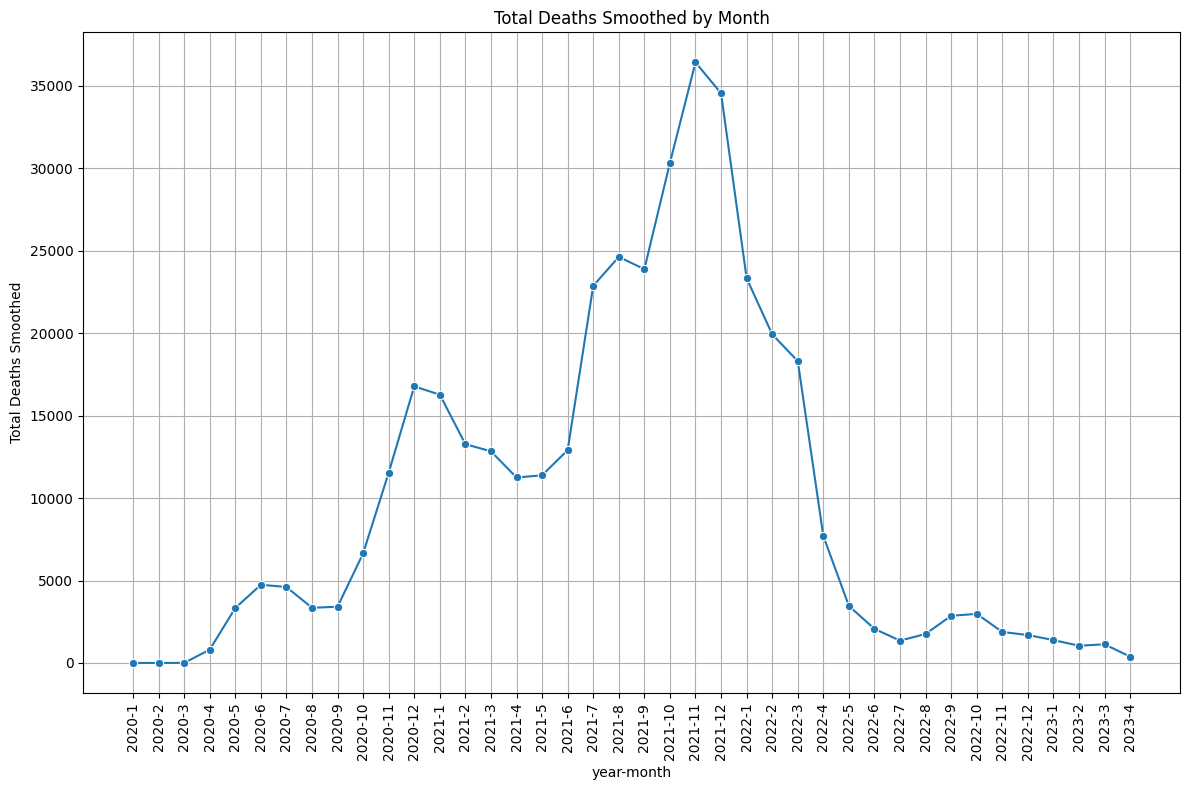

In [ ]:
russia_death_month_by_month=df[df['location']=='Russia'].groupby(['year','month'])['new_deaths_smoothed'].sum().reset_index()
russia_death_month_by_month['year-month']=russia_death_month_by_month['year'].astype(str)+'-'+russia_death_month_by_month['month'].astype(str)

plt.figure(figsize=(12,8))
sns.lineplot(x='year-month',y='new_deaths_smoothed',data=russia_death_month_by_month,marker='o')
plt.title('Total Deaths Smoothed by Month')
plt.xlabel('year-month')
plt.ylabel('Total Deaths Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell defines a list of European countries, filters the DataFrame for these countries, and aggregates 'new_deaths_smoothed' by 'year' and 'month'. It then creates a 'year-month' column and plots a line chart showing the smoothed death trend for the specified European countries over time.

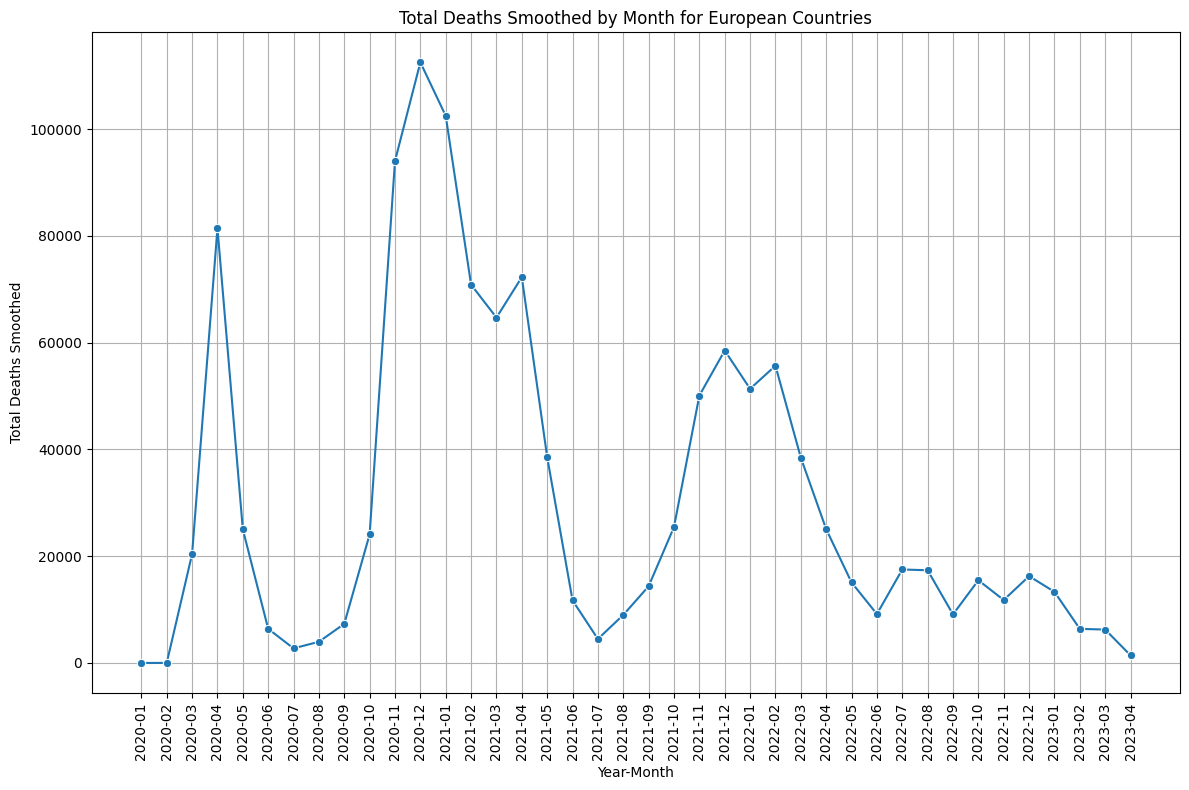

In [ ]:
european_countries = ['UK','Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Republic of Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain','Sweden']
Eu_death_month_by_month=df[df['location'].isin(european_countries)].groupby(['year','month'])['new_deaths_smoothed'].sum().reset_index()
Eu_death_month_by_month['year-month']=Eu_death_month_by_month['year'].astype(str)+'-'+Eu_death_month_by_month['month'].astype(str).str.zfill(2)

plt.figure(figsize=(12,8))
sns.lineplot(x='year-month',y='new_deaths_smoothed',data=Eu_death_month_by_month,marker='o')
plt.title('Total Deaths Smoothed by Month for European Countries')
plt.xlabel('Year-Month')
plt.ylabel('Total Deaths Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell combines death trend data for India, United States, China, Russia, European Countries, and the World into a single DataFrame. It then generates a multi-line plot, comparing the 'new_deaths_smoothed' trends for these different locations over time, using different colors for each location.

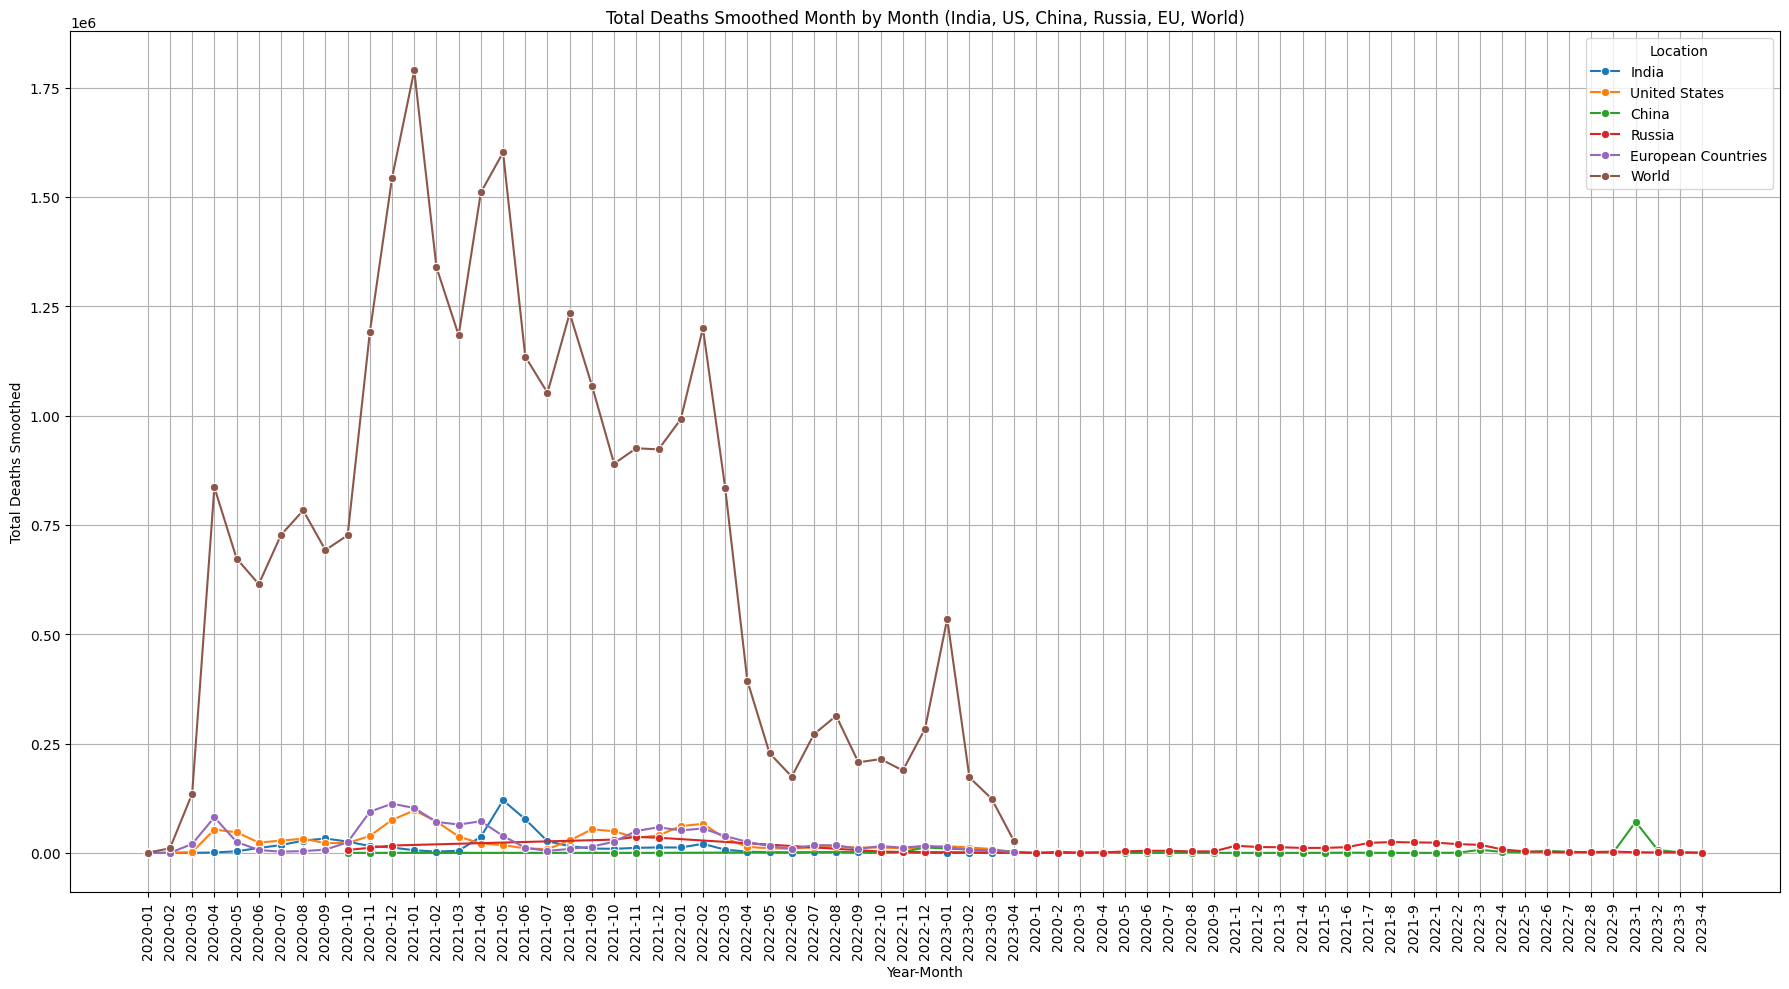

In [ ]:
world_death_month_by_month = df.groupby(['year', 'month'])['new_deaths_smoothed'].sum().reset_index()
world_death_month_by_month['year-month'] = world_death_month_by_month['year'].astype(str) + '-' + world_death_month_by_month['month'].astype(str).str.zfill(2)
world_death_month_by_month['location'] = 'World'

# Prepare individual country/region dataframes for concatenation
india_death_month_by_month['location'] = 'India'
us_death_month_by_month['location'] = 'United States'
china_death_month_by_month['location'] = 'China'
russia_death_month_by_month['location'] = 'Russia'
Eu_death_month_by_month['location'] = 'European Countries'

# Combine all dataframes
combined_deaths_df = pd.concat([
    india_death_month_by_month,
    us_death_month_by_month,
    china_death_month_by_month,
    russia_death_month_by_month,
    Eu_death_month_by_month,
    world_death_month_by_month
], ignore_index=True)

plt.figure(figsize=(18, 10))
sns.lineplot(x='year-month', y='new_deaths_smoothed', hue='location', data=combined_deaths_df, marker='o')
plt.title('Total Deaths Smoothed Month by Month (India, US, China, Russia, EU, World)')
plt.xlabel('Year-Month')
plt.ylabel('Total Deaths Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Location')
plt.tight_layout()
plt.show()

This cell prepares dataframes for 'new_cases_smoothed' trends for India, United States, China, Russia, European Countries, and the World, similar to the death trends. It then concatenates these dataframes and plots a multi-line chart to visualize and compare the smoothed case trends for these locations over time.

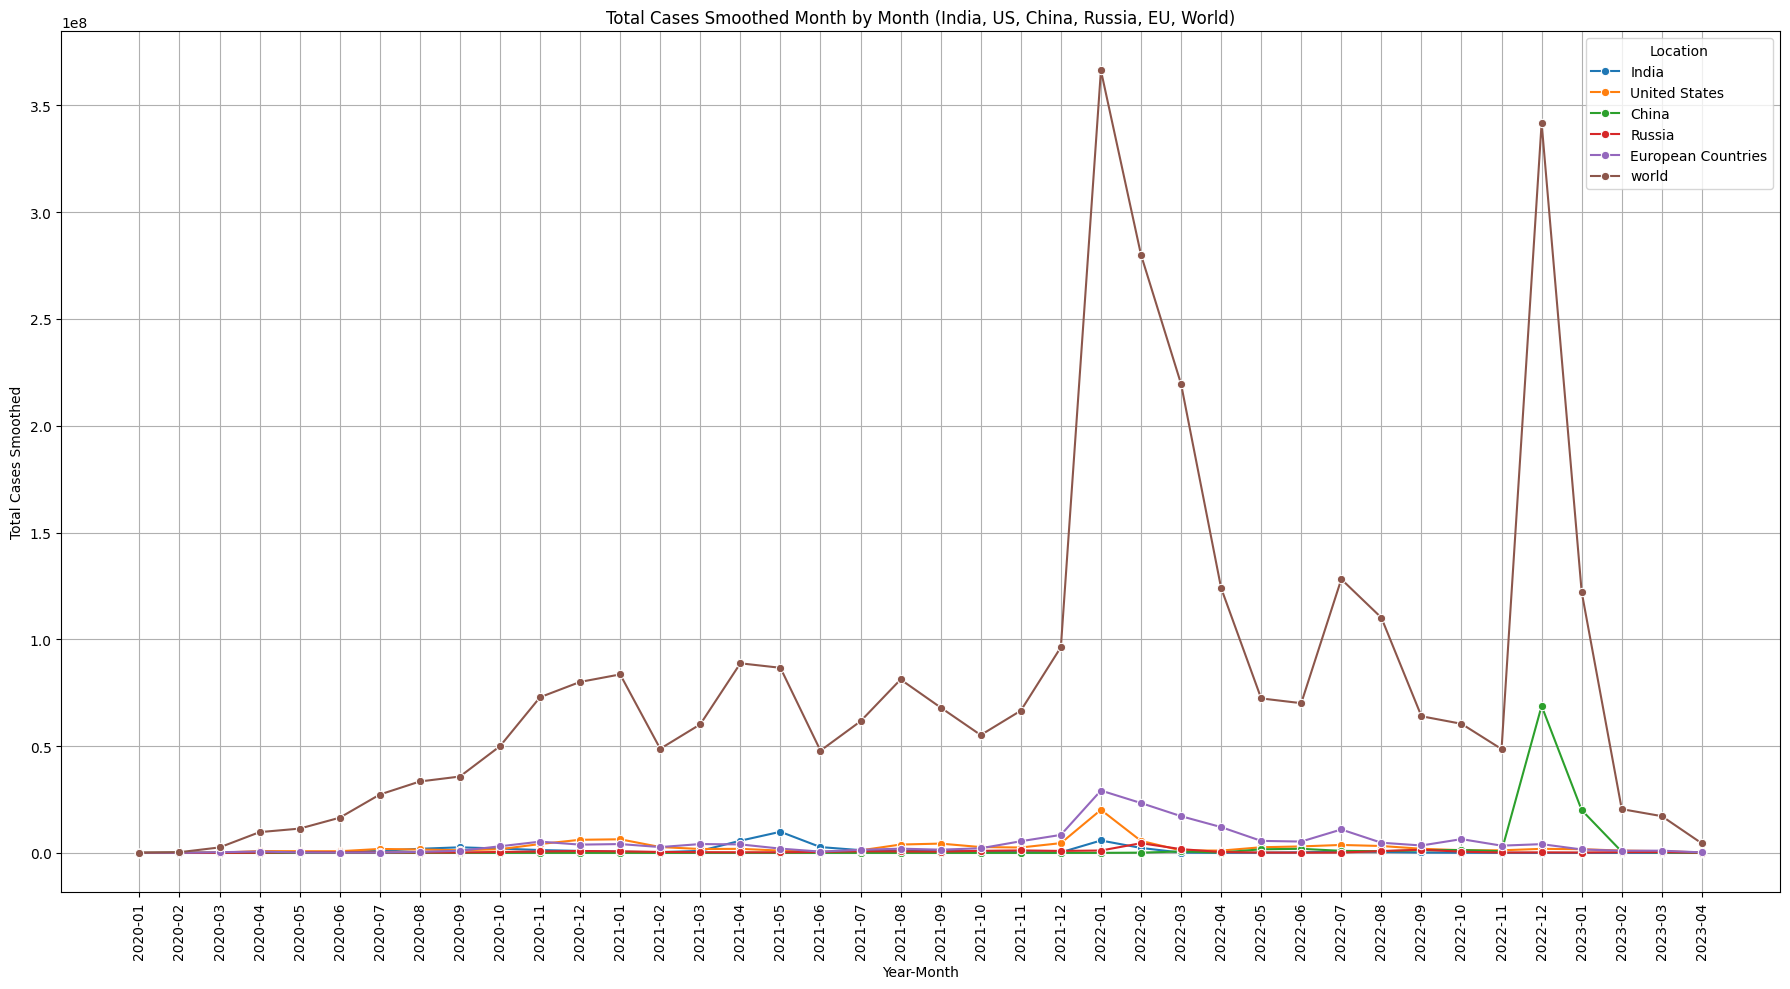

In [ ]:
world_cases_by_cases=df.groupby(['year','month'])['new_cases_smoothed'].sum().reset_index()
world_cases_by_cases['year-month']=world_cases_by_cases['year'].astype(str)+'-'+world_cases_by_cases['month'].astype(str).str.zfill(2)
world_cases_by_cases['location']='world'

india_cases_by_cases=df[df['location']=='India'].groupby(['year','month'])['new_cases_smoothed'].sum().reset_index()
india_cases_by_cases['year-month']=india_cases_by_cases['year'].astype(str)+'-'+india_cases_by_cases['month'].astype(str).str.zfill(2)
india_cases_by_cases['location']='India'

us_cases_by_cases=df[df['location']=='United States'].groupby(['year','month'])['new_cases_smoothed'].sum().reset_index()
us_cases_by_cases['year-month']=us_cases_by_cases['year'].astype(str)+'-'+us_cases_by_cases['month'].astype(str).str.zfill(2)
us_cases_by_cases['location']='United States'

china_cases_by_cases=df[df['location']=='China'].groupby(['year','month'])['new_cases_smoothed'].sum().reset_index()
china_cases_by_cases['year-month']=china_cases_by_cases['year'].astype(str)+'-'+china_cases_by_cases['month'].astype(str).str.zfill(2)
china_cases_by_cases['location']='China'

russia_cases_by_cases=df[df['location']=='Russia'].groupby(['year','month'])['new_cases_smoothed'].sum().reset_index()
russia_cases_by_cases['year-month']=russia_cases_by_cases['year'].astype(str)+'-'+russia_cases_by_cases['month'].astype(str).str.zfill(2)
russia_cases_by_cases['location']='Russia'

eu_cases_by_cases=df[df['location'].isin(european_countries)].groupby(['year','month'])['new_cases_smoothed'].sum().reset_index()
eu_cases_by_cases['year-month']=eu_cases_by_cases['year'].astype(str)+'-'+eu_cases_by_cases['month'].astype(str).str.zfill(2)
eu_cases_by_cases['location']='European Countries'

combine_cases=pd.concat([
    india_cases_by_cases,
    us_cases_by_cases,
    china_cases_by_cases,
    russia_cases_by_cases,
    eu_cases_by_cases,
    world_cases_by_cases
],ignore_index=True)

plt.figure(figsize=(18,10))
sns.lineplot(x='year-month',y='new_cases_smoothed',hue='location',data=combine_cases,marker='o')
plt.title('Total Cases Smoothed Month by Month (India, US, China, Russia, EU, World)')
plt.xlabel('Year-Month')
plt.ylabel('Total Cases Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Location')
plt.tight_layout()
plt.show()

### Top 10 Countries by Total Smoothed Deaths

This cell filters out 'Unknown' continents, then calculates the top 10 countries with the highest total 'new_deaths_smoothed'. It then visualizes this data using a bar plot, showing the total deaths for each of the top 10 countries.

/tmp/ipykernel_172/1649411370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location',y='new_deaths_smoothed',data=top_10_deaths_countries,palette='viridis')


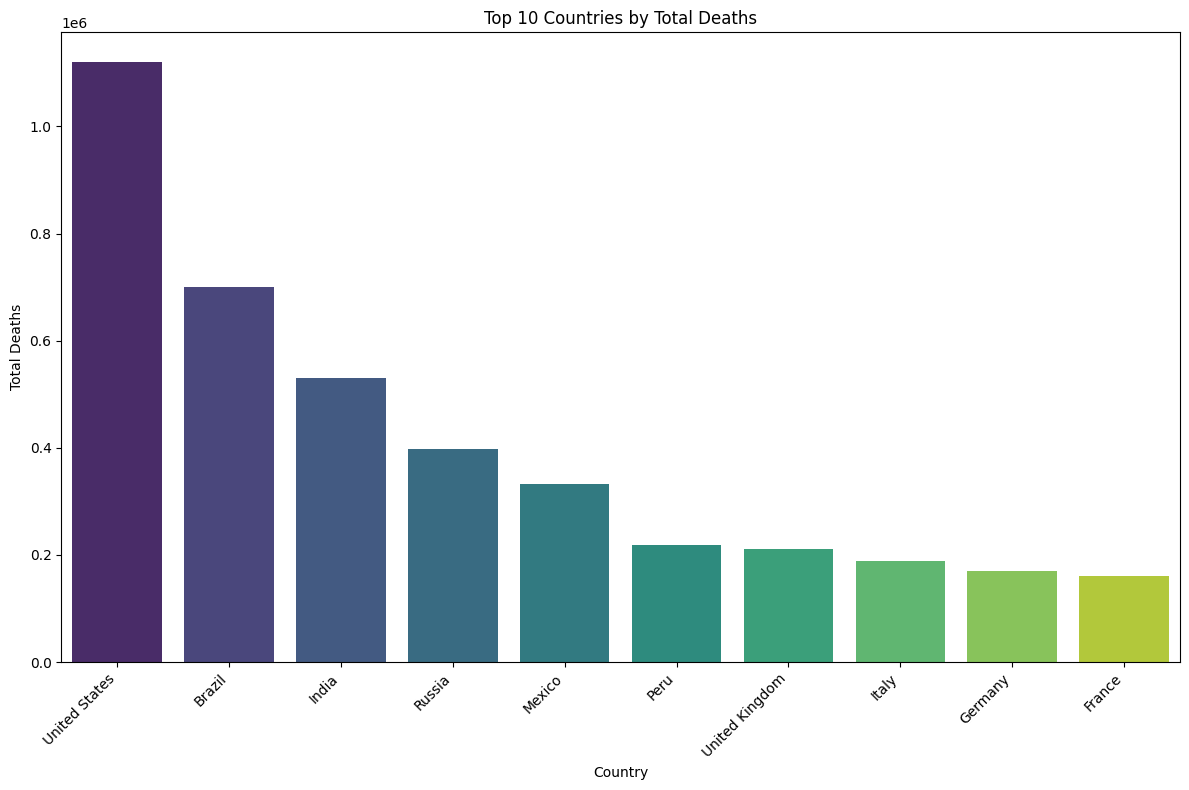

In [ ]:
filtered_df = df[df['continent'] != 'Unknown']
top_10_deaths_countries = filtered_df.groupby('location')['new_deaths_smoothed'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,8))
sns.barplot(x='location',y='new_deaths_smoothed',data=top_10_deaths_countries,palette='viridis')
plt.title('Top 10 Countries by Total Deaths')
plt.xlabel('Country')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

### Monthly Total New Cases Smoothed by Continent

This cell filters out 'Unknown' continents, aggregates 'new_cases_smoothed' by 'year', 'month', and 'continent', and creates a 'year-month' column. It then plots a multi-line chart to visualize the monthly total new cases smoothed for each continent over time.

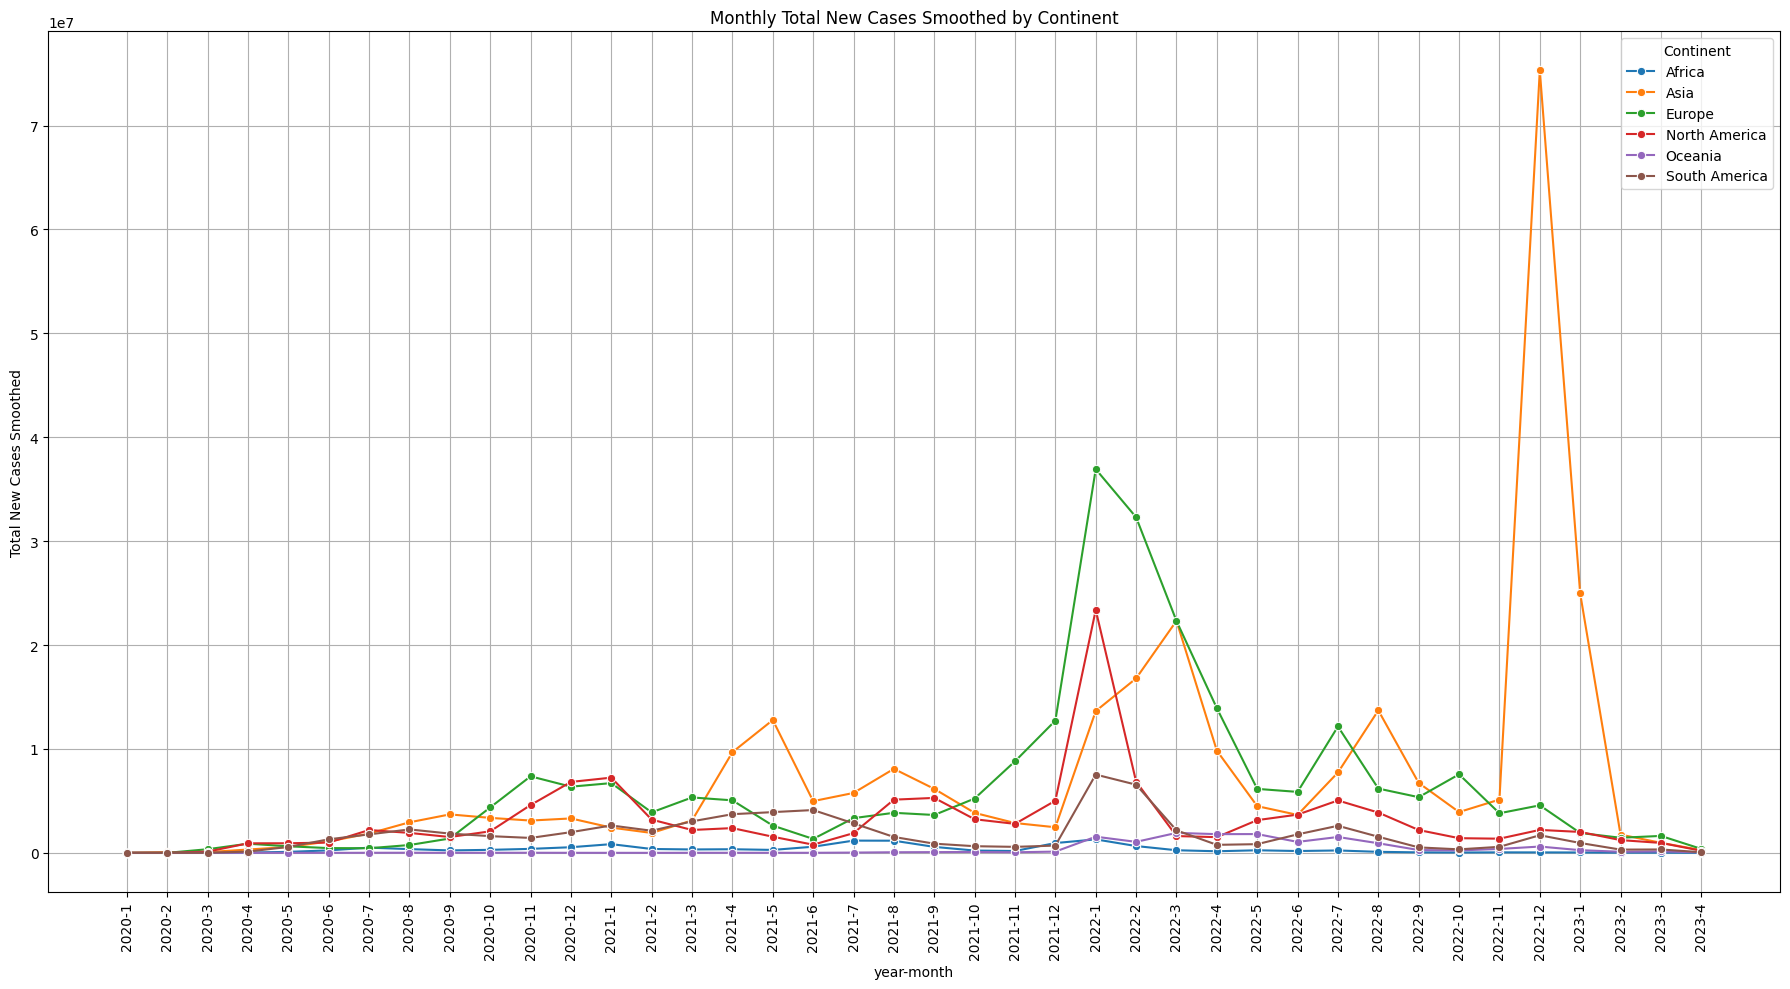

In [ ]:



filtered_df=df[df['continent']!='Unknown']
cases_continent_by_month=filtered_df.groupby(['year','month','continent'])['new_cases_smoothed'].sum().reset_index()
cases_continent_by_month['year-month']=cases_continent_by_month['year'].astype(str)+'-'+cases_continent_by_month['month'].astype(str)

plt.figure(figsize=(18,10))
sns.lineplot(x='year-month',y='new_cases_smoothed',hue='continent',data=cases_continent_by_month,marker='o')
plt.title('Monthly Total New Cases Smoothed by Continent')
plt.xlabel('year-month')
plt.ylabel('Total New Cases Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Continent')
plt.tight_layout()
plt.show()

### Total Cases vs. Total Deaths by Country (Latest Data)

This cell identifies the latest data entry for each country based on year, month, and day. It then filters out 'World' entries, 'Unknown' continents, and countries with zero total cases. Finally, it generates a scatter plot comparing 'total_cases' and 'total_deaths' for each country, colored by continent and sized by total cases, using logarithmic scales for better visualization.

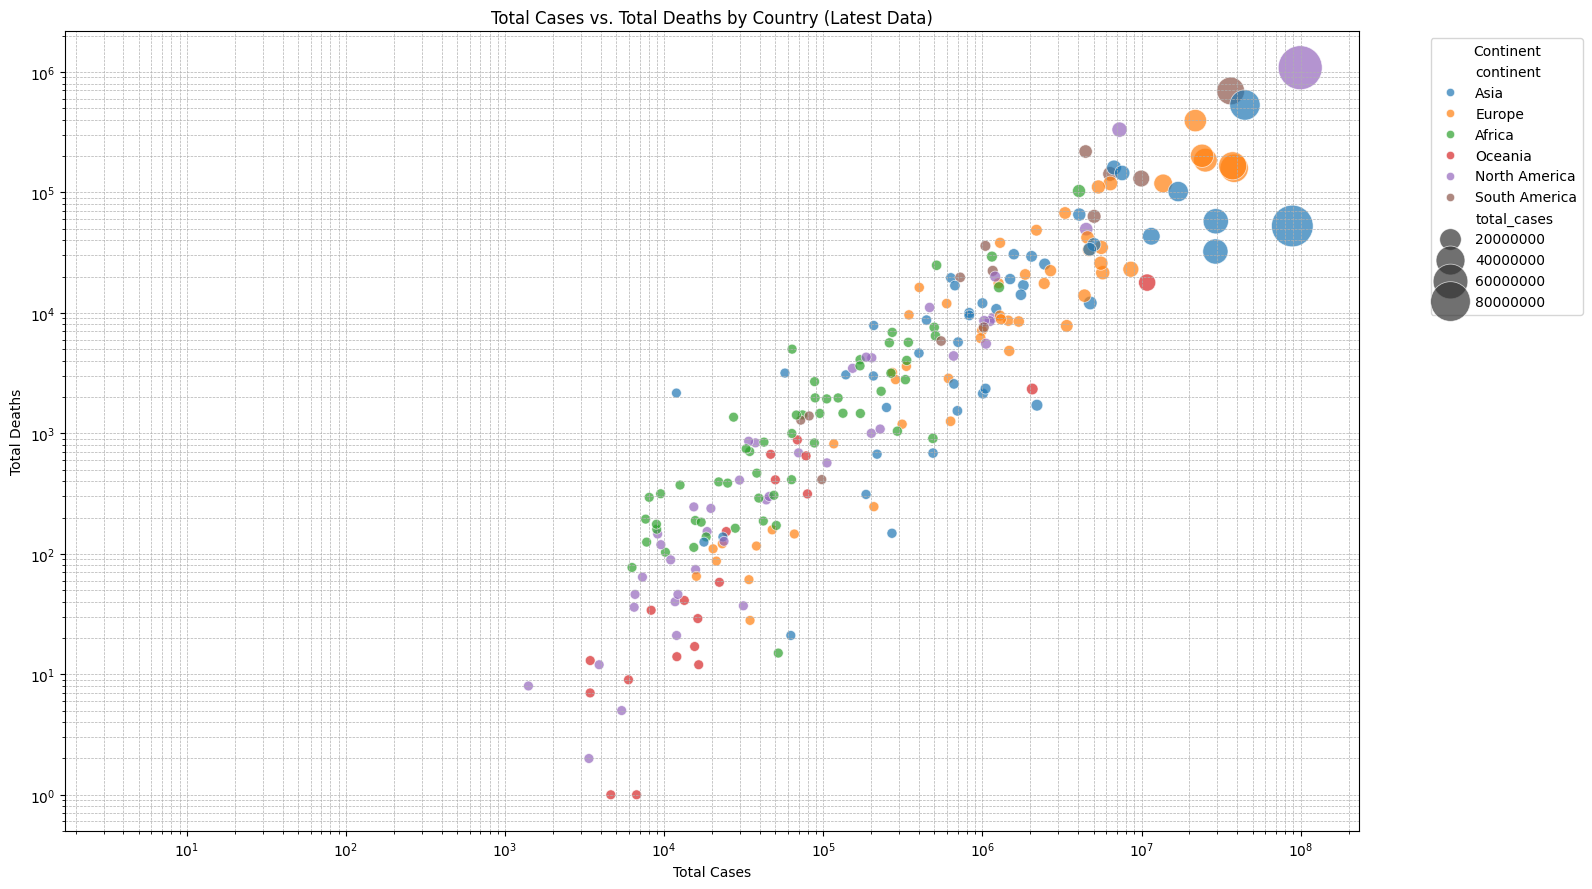

In [ ]:

latest_data_per_country=df.loc[df.groupby('location')['year'].idxmax()]
latest_data_per_country=latest_data_per_country.loc[latest_data_per_country.groupby('location')['month'].idxmax()]
latest_data_per_country=latest_data_per_country.loc[latest_data_per_country.groupby('location')['day'].idxmax()]

latest_data_per_country=latest_data_per_country[(latest_data_per_country['location']!='world')&(latest_data_per_country['continent']!='Unknown')&(latest_data_per_country['total_cases']>0)].copy()
plt.figure(figsize=(16,9))

sns.scatterplot(x='total_cases',y='total_deaths',hue='continent',size='total_cases',sizes=(50,1000),data=latest_data_per_country,alpha=0.7)
plt.title('Total Cases vs. Total Deaths by Country (Latest Data)')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.xscale('log')
plt.yscale('log')
plt.grid(True,which='both',linestyle='--',linewidth=0.5)
plt.legend(title='Continent',bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

This cell filters out 'Unknown' continents, aggregates 'new_deaths_smoothed' by 'year', 'month', and 'continent', and creates a 'year-month' column. It then plots a multi-line chart to visualize the monthly total new deaths smoothed for each continent over time.

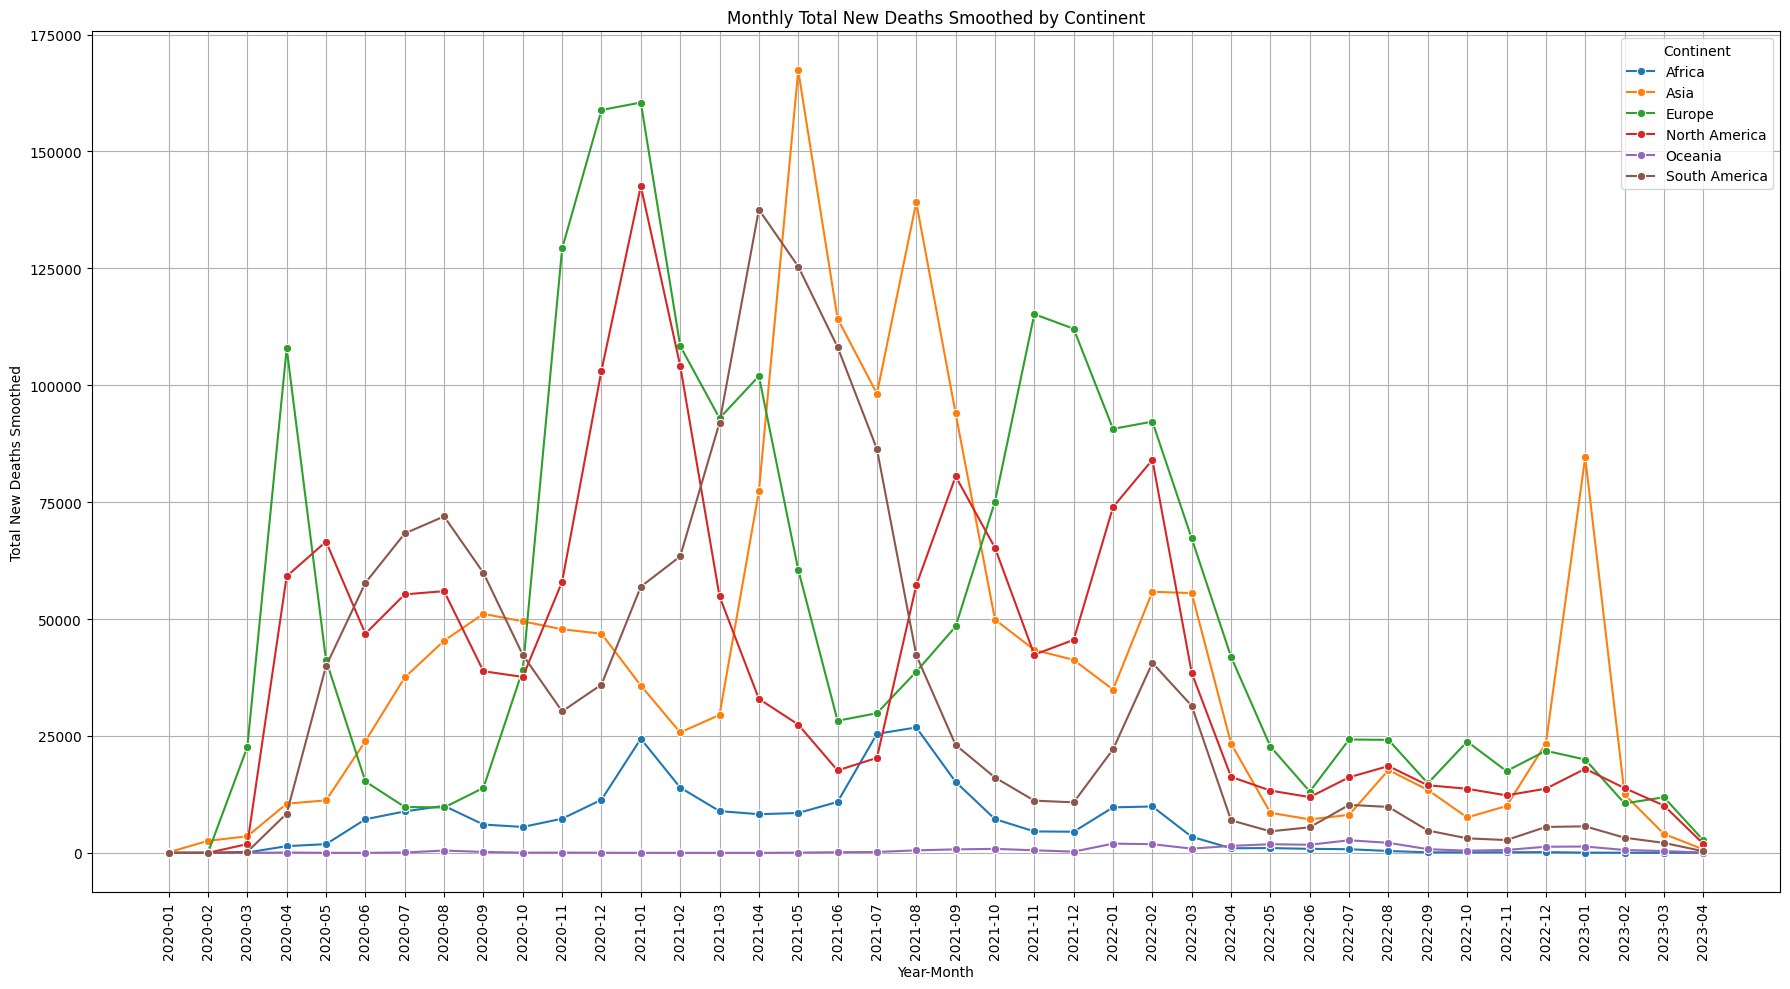

In [ ]:
filtered_df = df[df['continent'] != 'Unknown']
deaths_continent_by_month = filtered_df.groupby(['year', 'month', 'continent'])['new_deaths_smoothed'].sum().reset_index()
deaths_continent_by_month['year-month'] = deaths_continent_by_month['year'].astype(str) + '-' + deaths_continent_by_month['month'].astype(str).str.zfill(2)

plt.figure(figsize=(18, 10))
sns.lineplot(x='year-month', y='new_deaths_smoothed', hue='continent', data=deaths_continent_by_month, marker='o')
plt.title('Monthly Total New Deaths Smoothed by Continent')
plt.xlabel('Year-Month')
plt.ylabel('Total New Deaths Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Continent')
plt.tight_layout()
plt.show()

Here is the trend for the total cases smoothed by continent:

This cell filters out 'Unknown' continents, aggregates 'new_cases_smoothed' by 'year', 'month', and 'continent', and creates a 'year-month' column. It then plots a multi-line chart to visualize the monthly total new cases smoothed for each continent over time.


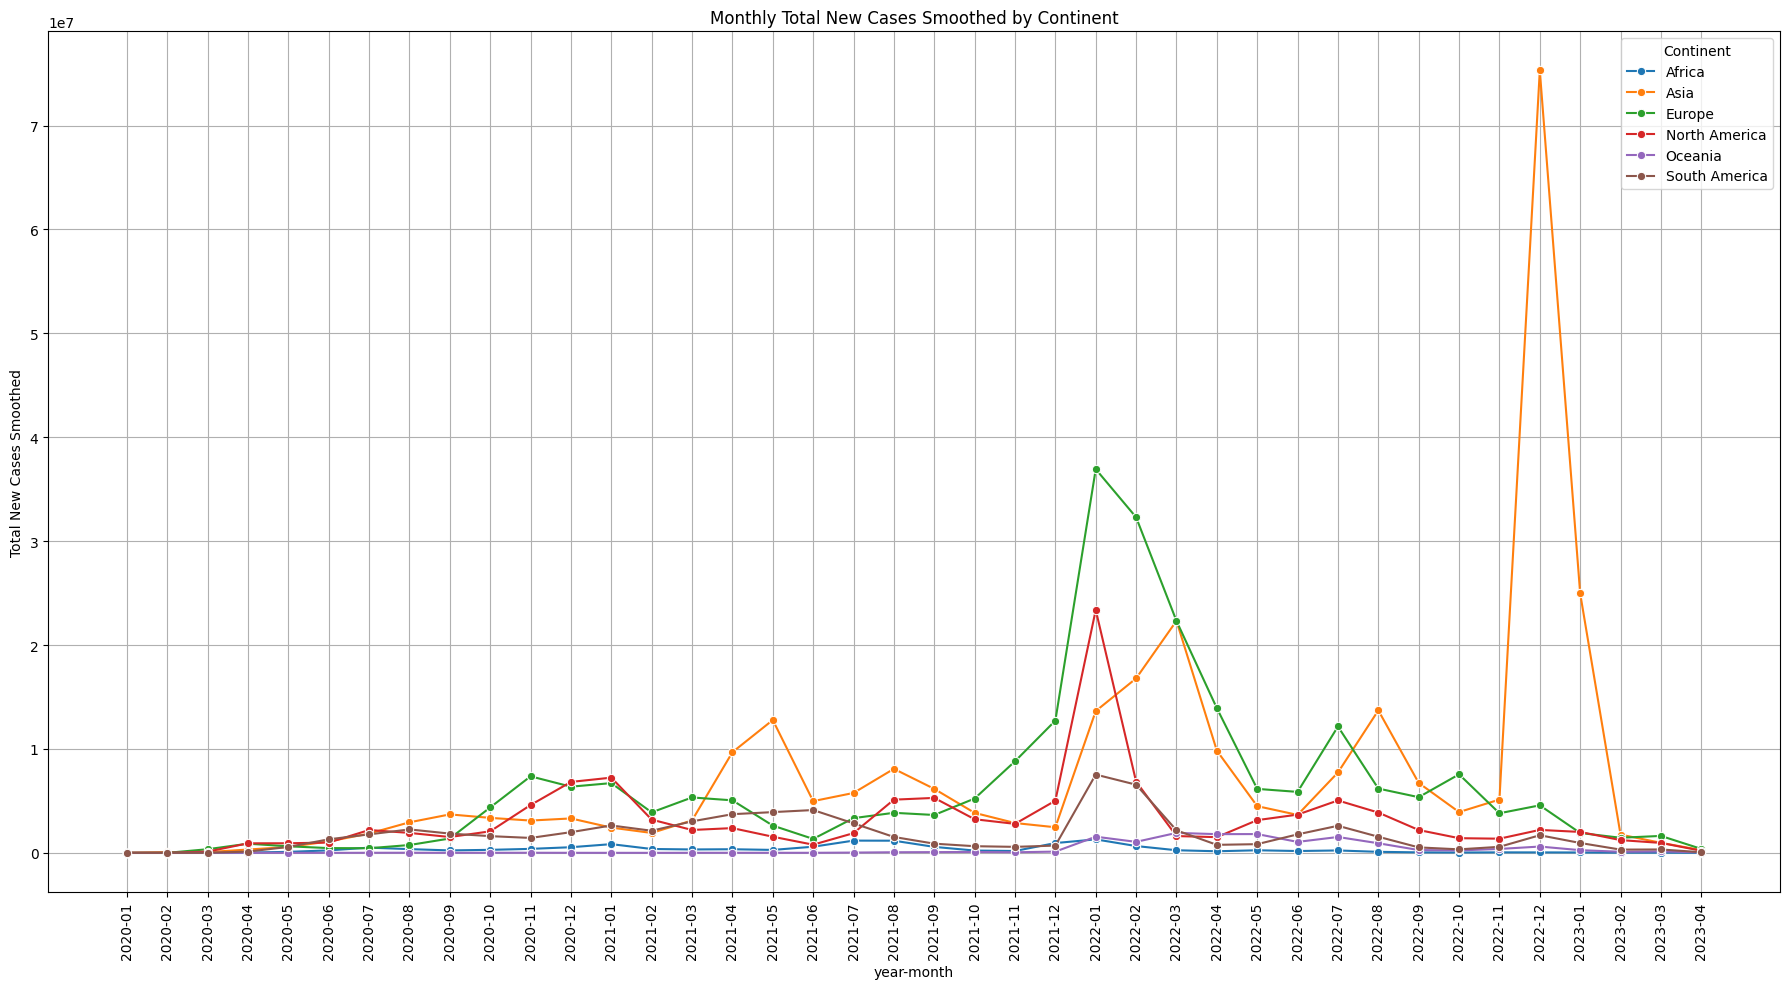

In [ ]:
filtered_df=df[df['continent']!='Unknown']
cases_continent_by_month=filtered_df.groupby(['year','month','continent'])['new_cases_smoothed'].sum().reset_index()
cases_continent_by_month['year-month']=cases_continent_by_month['year'].astype(str)+'-'+cases_continent_by_month['month'].astype(str).str.zfill(2)

plt.figure(figsize=(18,10))
sns.lineplot(x='year-month',y='new_cases_smoothed',hue='continent',data=cases_continent_by_month,marker='o')
plt.title('Monthly Total New Cases Smoothed by Continent')
plt.xlabel('year-month')
plt.ylabel('Total New Cases Smoothed')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Continent')
plt.tight_layout()
plt.show()